# Medical Diagnosis Support: Disease Classification Using Decision Trees
### Dataset: Early Stage Diabetes Risk Prediction
##### Educational Disclaimer
This notebook is developed solely for educational and research purposes. The resulting predictive models are NOT clinically validated and must NOT be used for diagnosis, treatment planning, patient triage, or any real-world healthcare decision.

# 1. Environment Setup

In [10]:
# =============================================================================
# 1. ENVIRONMENT SETUP
# =============================================================================
import os
import json
import random
import warnings
import platform
from pathlib import Path
from datetime import datetime

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn
import sklearn
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV,
    RandomizedSearchCV, cross_validate, cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, matthews_corrcoef, brier_score_loss,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.inspection import permutation_importance

# Persistence
import joblib

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

# Visualization style
plt.style.use("ggplot")
sns.set_context("talk")

# Reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("=" * 60)
print("Environment Information")
print("=" * 60)
print(f"Python Version     : {platform.python_version()}")
print(f"Pandas Version     : {pd.__version__}")
print(f"NumPy Version      : {np.__version__}")
print(f"Scikit-Learn Version: {sklearn.__version__}")
print(f"Random State       : {RANDOM_STATE}")
print("=" * 60)
# Create directory for report-quality figures
os.makedirs("report_figures", exist_ok=True)


Environment Information
Python Version     : 3.10.0
Pandas Version     : 2.3.2
NumPy Version      : 2.2.6
Scikit-Learn Version: 1.7.2
Random State       : 42


# 2. Business Understanding & Problem Framing

### Problem Statement
Early detection of diabetes can significantly reduce long-term complications.  
This notebook builds an interpretable binary classifier that predicts whether an individual is at **positive** risk for early-stage diabetes based on readily available demographic and symptom data.

### Prediction Task
| Item | Specification |
|:---|:---|
| **Observation Unit** | One individual respondent |
| **Target Variable** | Diabetes risk status (`class`) |
| **Positive Class** | `Positive` (diabetes risk present) â†’ encoded as **1** |
| **Negative Class** | `Negative` (diabetes risk absent) â†’ encoded as **0** |
| **Prediction Time** | All predictors are assumed available before a clinical work-up |
| **Intended Use** | Educational predictive-analytics prototype only |
| **Out of Scope** | Must never be used for medical diagnosis, treatment recommendation, or patient triage |

### Error Priority
In a screening context, **false negatives** (missing an at-risk patient) are typically more costly than false positives. Therefore we emphasise **sensitivity** during threshold selection while monitoring specificity and precision.

# 3. Dataset Loading & Provenance

In [11]:
# =============================================================================
# 3. DATASET LOADING
# =============================================================================
DATA_PATH = "..\data\diabetes_risk_prediction.csv"

df = pd.read_csv(DATA_PATH)

# Target encoding: Positive = 1 (disease present), Negative = 0
TARGET_COL = "class"
df[TARGET_COL] = df[TARGET_COL].map({"Positive": 1, "Negative": 0})

# Separate features and target
X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].copy()
y.name = "DiabetesRisk"

print("=" * 60)
print("Dataset Summary")
print("=" * 60)
print(f"Rows     : {df.shape[0]}")
print(f"Columns  : {df.shape[1]}")
print(f"Features : {X.shape[1]}")
print(f"Classes  : {y.nunique()}")
print("\nTarget Mapping")
print("1 -> Positive (Diabetes risk)")
print("0 -> Negative (No diabetes risk)")
print("\nClass Distribution")
print(y.value_counts().sort_index())

Dataset Summary
Rows     : 520
Columns  : 17
Features : 16
Classes  : 2

Target Mapping
1 -> Positive (Diabetes risk)
0 -> Negative (No diabetes risk)

Class Distribution
DiabetesRisk
0    200
1    320
Name: count, dtype: int64


# 4. Data Understanding & Audit

In [12]:
# =============================================================================
# 4. DATA UNDERSTANDING
# =============================================================================
print("=" * 60)
print("Dataset Shape")
print("=" * 60)
print(f"Rows     : {df.shape[0]}")
print(f"Columns  : {df.shape[1]}")
print(f"Features : {X.shape[1]}")
print(f"Target   : {y.name}")

display(df.head())

# Data types
print("\nData Types")
dtype_table = pd.DataFrame({
    "Feature": X.columns,
    "Data Type": X.dtypes.values
})
display(dtype_table)

# Statistical summary for age; value counts for categorical symptoms
print("\nNumerical Summary (Age)")
display(X[["age"]].describe().T)

# Missing values
missing = pd.DataFrame({
    "Missing Values": X.isna().sum(),
    "Percentage": (X.isna().mean() * 100).round(2)
})
print("\nMissing Values")
display(missing.sort_values("Missing Values", ascending=False))

# Duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows : {duplicates}")

# Constant / quasi-constant features
constant = [c for c in X.columns if X[c].nunique() == 1]
print(f"Constant Features : {constant}")

# Unique values per column (useful for identifying categoricals)
uniq = pd.DataFrame({
    "Feature": X.columns,
    "Unique Values": X.nunique().values
})
print("\nUnique Value Counts")
display(uniq.sort_values("Unique Values"))

# Target distribution
target_counts = y.value_counts().sort_index()
target_percent = y.value_counts(normalize=True).sort_index() * 100
target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent.round(2)
})
print("\nTarget Distribution")
display(target_summary)

Dataset Shape
Rows     : 520
Columns  : 17
Features : 16
Target   : DiabetesRisk


,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,1
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,1
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,1
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,1
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,1



Data Types


,Feature,Data Type
0,age,int64
1,gender,object
2,polyuria,object
3,polydipsia,object
4,sudden_weight_loss,object
5,weakness,object
6,polyphagia,object
7,genital_thrush,object
8,visual_blurring,object
9,itching,object



Numerical Summary (Age)


...

,Missing Values,Percentage
age,0,0.0000
gender,0,0.0000
polyuria,0,0.0000
polydipsia,0,0.0000
sudden_weight_loss,0,0.0000
weakness,0,0.0000
polyphagia,0,0.0000
genital_thrush,0,0.0000
visual_blurring,0,0.0000
itching,0,0.0000



Duplicate Rows : 269
Constant Features : []

Unique Value Counts


,Feature,Unique Values
1,gender,2
2,polyuria,2
3,polydipsia,2
4,sudden_weight_loss,2
6,polyphagia,2
5,weakness,2
7,genital_thrush,2
8,visual_blurring,2
12,partial_paresis,2
9,itching,2



Target Distribution


,Count,Percentage
DiabetesRisk,,
0,200,38.4600
1,320,61.5400


## 4.1 Target Distribution Plot


C:\Users\apara\AppData\Local\Temp\ipykernel_20108\1915384464.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="Set2", ax=ax)
C:\Users\apara\AppData\Local\Temp\ipykernel_20108\1915384464.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Negative", "Positive"])


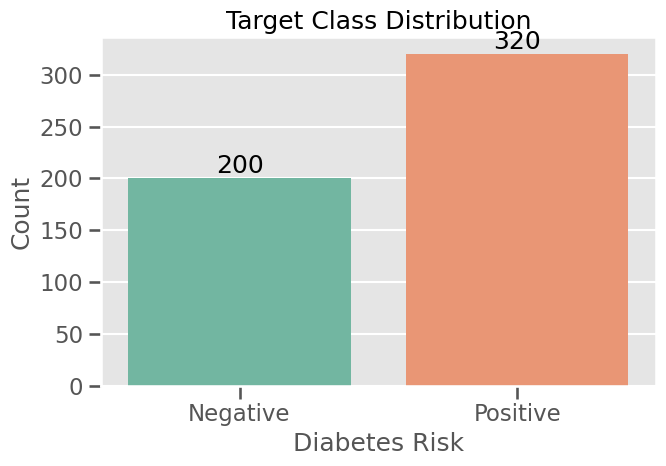

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(x=y, palette="Set2", ax=ax)
for container in ax.containers:
    ax.bar_label(container)
ax.set_xticklabels(["Negative", "Positive"])
ax.set_xlabel("Diabetes Risk")
ax.set_ylabel("Count")
ax.set_title("Target Class Distribution")
plt.tight_layout()
plt.savefig("report_figures/fig1_target_dist_dia.png", dpi=300, bbox_inches="tight")
# plt.show()  # commented: figure saved for report

## 4.2 Feature Distributions by Class


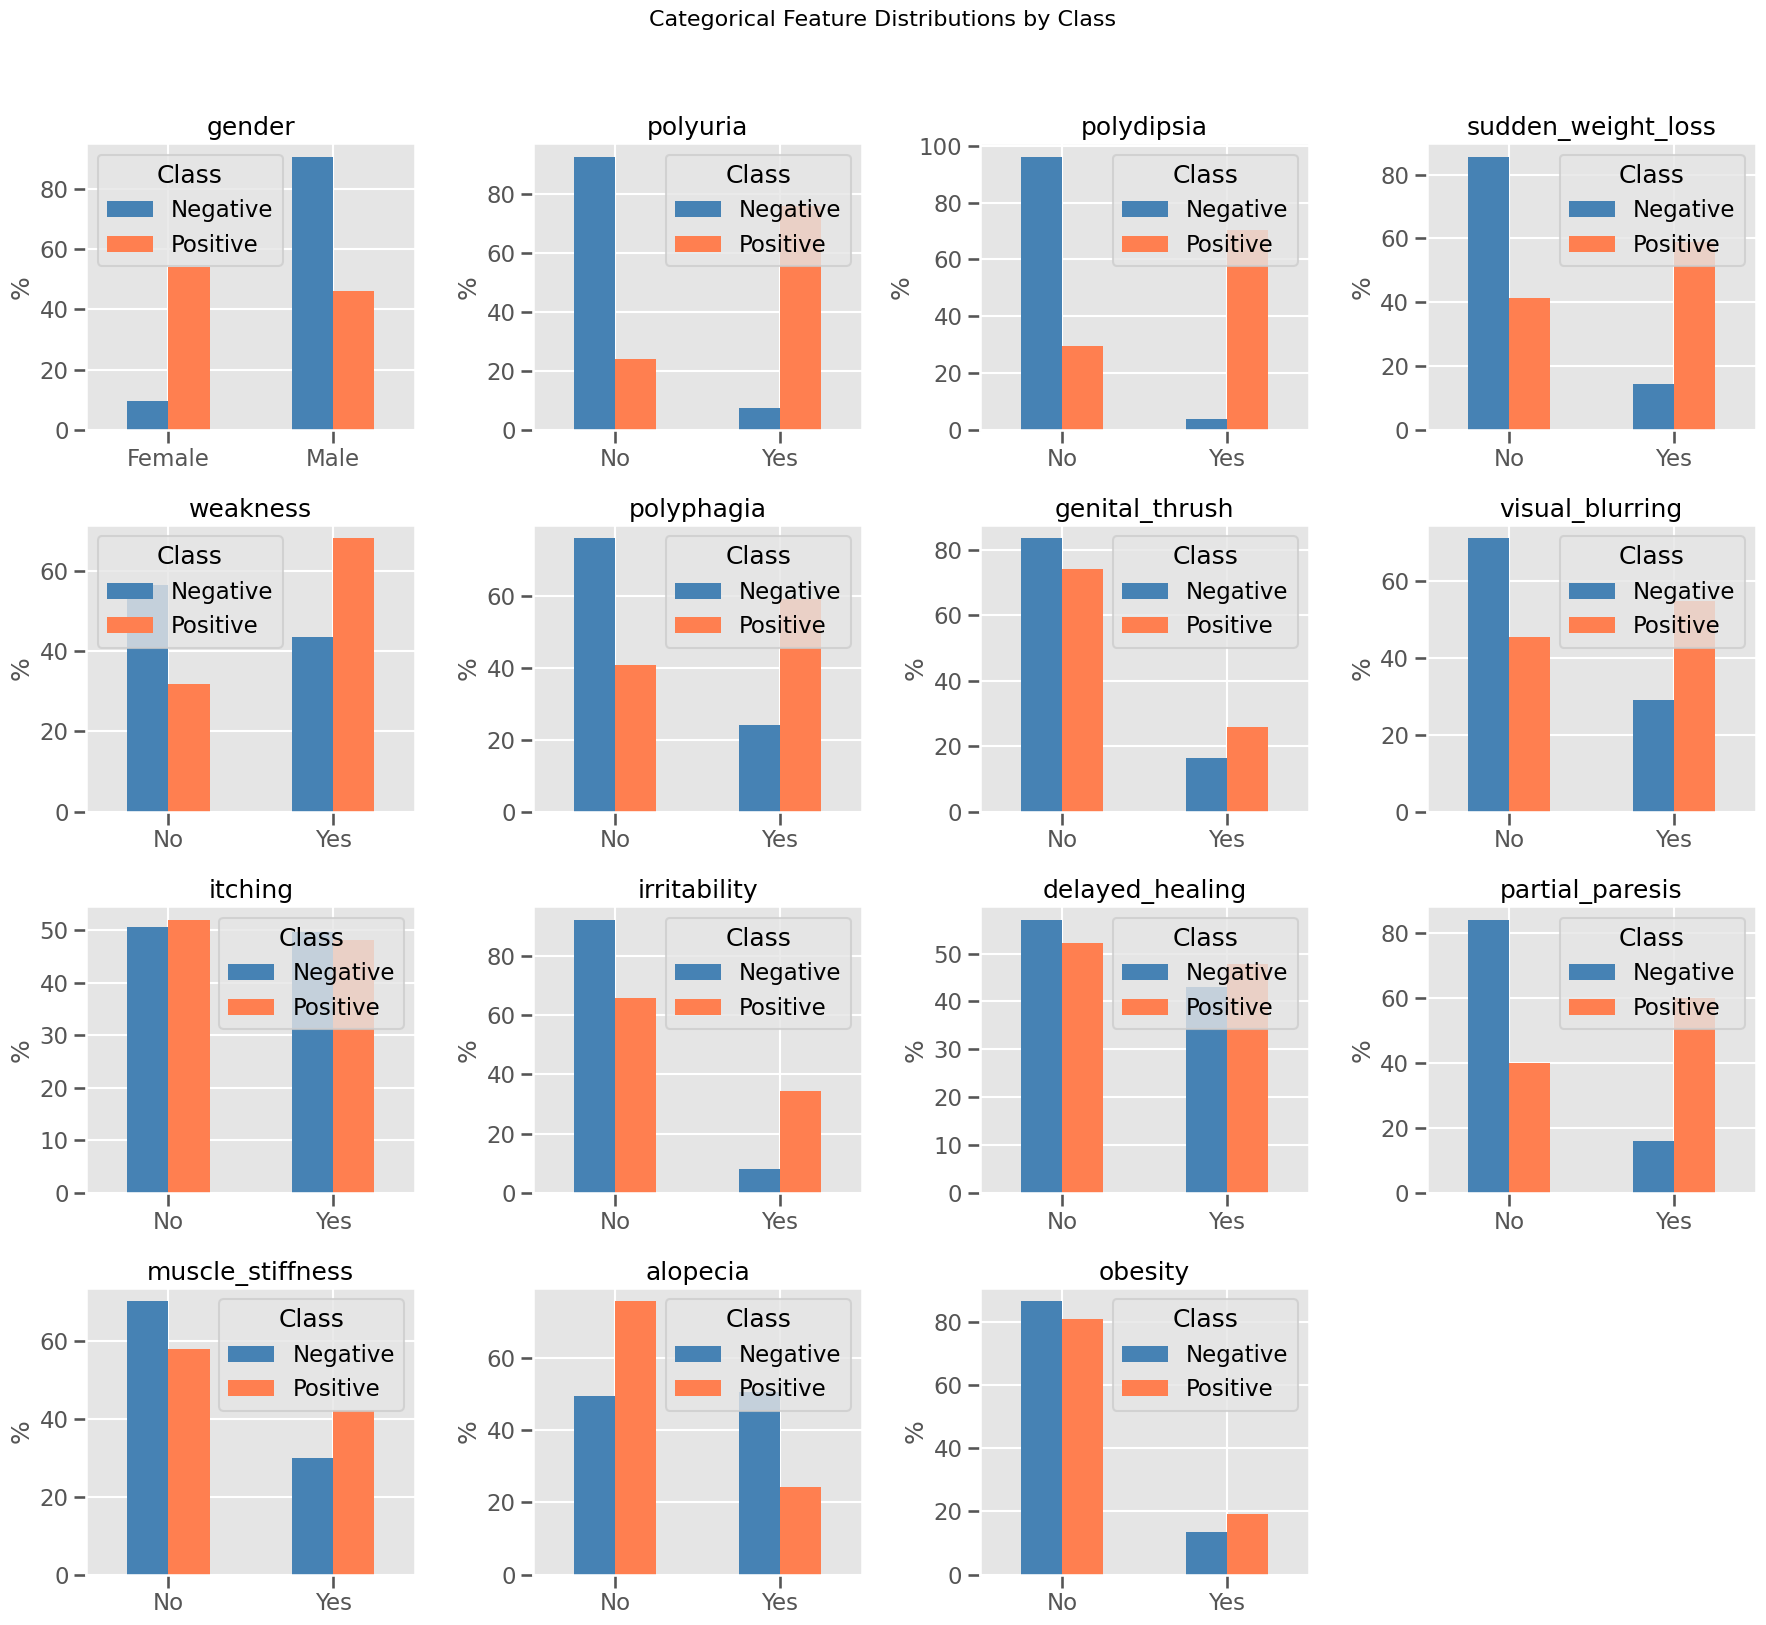

In [14]:
# For categorical features, show stacked bar of Yes/No proportions by class
cat_features = [c for c in X.columns if c != "age"]

n_cols = 4
n_rows = int(np.ceil(len(cat_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, cat_features):
    crosstab = pd.crosstab(X[col], y, normalize="columns") * 100
    crosstab.plot(kind="bar", ax=ax, color=["steelblue", "coral"])
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("%")
    ax.legend(["Negative", "Positive"], title="Class")
    ax.tick_params(axis="x", rotation=0)

for ax in axes[len(cat_features):]:
    ax.remove()

plt.suptitle("Categorical Feature Distributions by Class", y=1.02, fontsize=16)
plt.tight_layout()
plt.savefig("report_figures/fig1b_categorical_distributions.png", dpi=300, bbox_inches="tight")
# plt.show()  # commented: figure saved for report

## 4.3 Age Distribution by Class


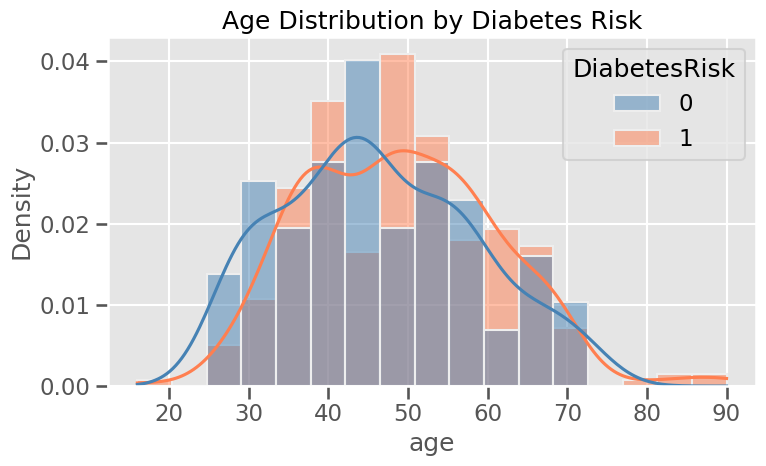

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df, x="age", hue=y, kde=True, stat="density",
             common_norm=False, palette=["steelblue", "coral"], ax=ax)
ax.set_title("Age Distribution by Diabetes Risk")
plt.tight_layout()
plt.savefig("report_figures/fig1c_age_distribution.png", dpi=300, bbox_inches="tight")
# plt.show()  # commented: figure saved for report

## 4.4 Correlation Matrix


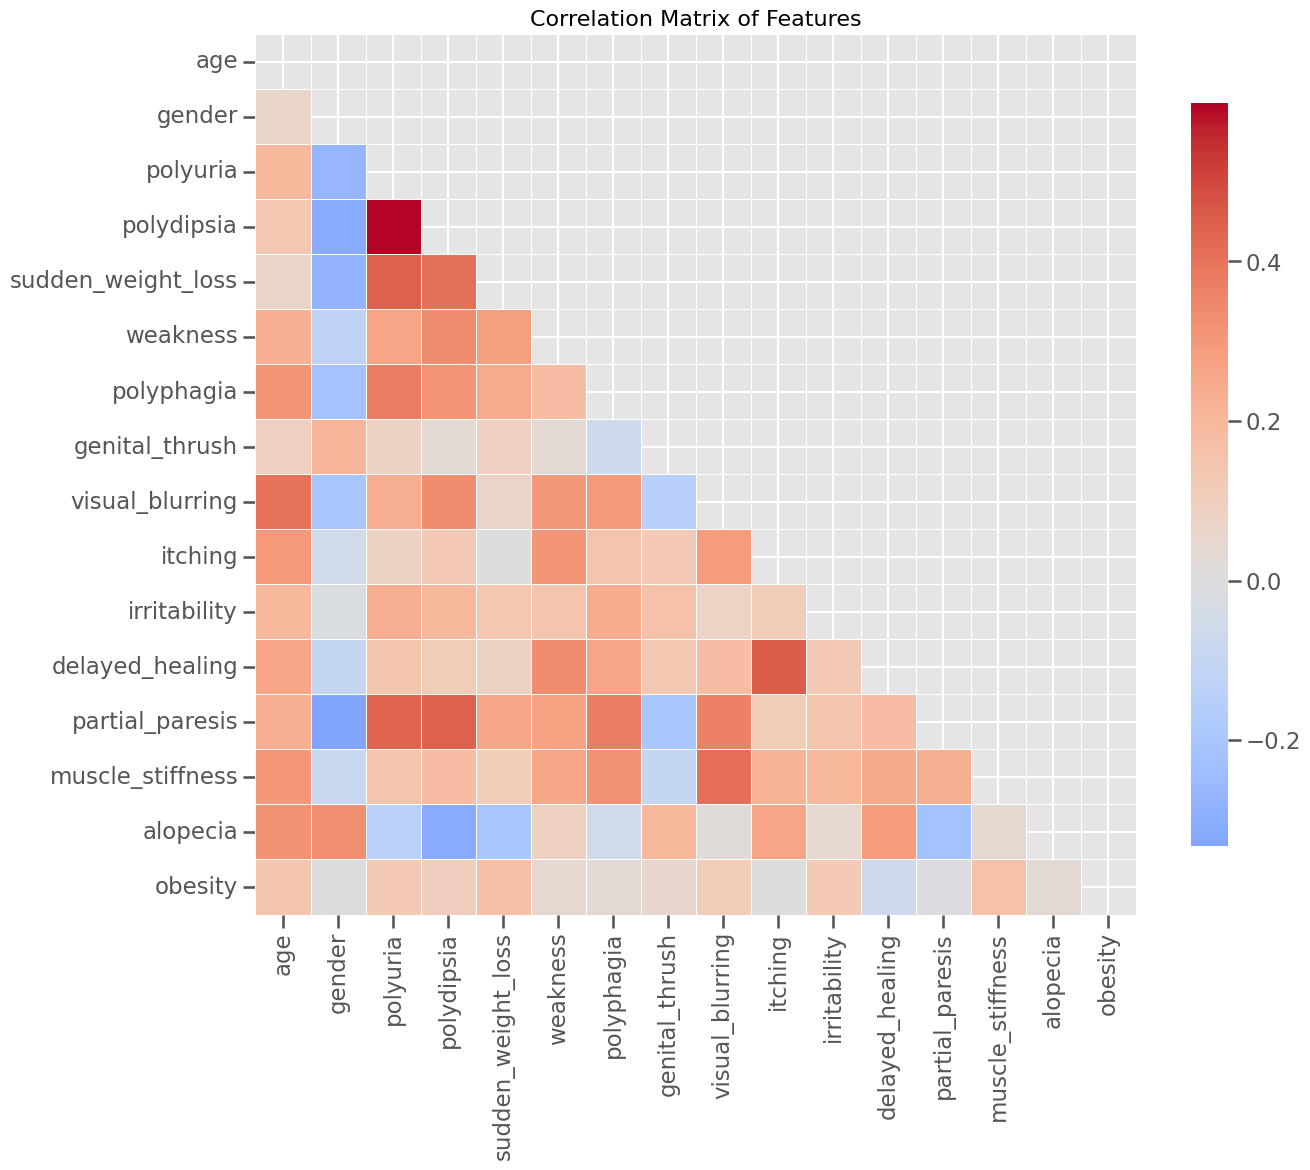

In [16]:
# Encode categoricals temporarily for correlation visualization
X_corr = X.copy()
for col in cat_features:
    X_corr[col] = X_corr[col].map({"Yes": 1, "No": 0, "Male": 1, "Female": 0})

corr_matrix = X_corr.corr()
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix of Features", fontsize=16)
plt.tight_layout()
plt.savefig("report_figures/fig2_correlation_matrix_dia.png", dpi=300, bbox_inches="tight")
# plt.show()  # commented: figure saved for report

## 4.5 Featureâ€“Target Correlation

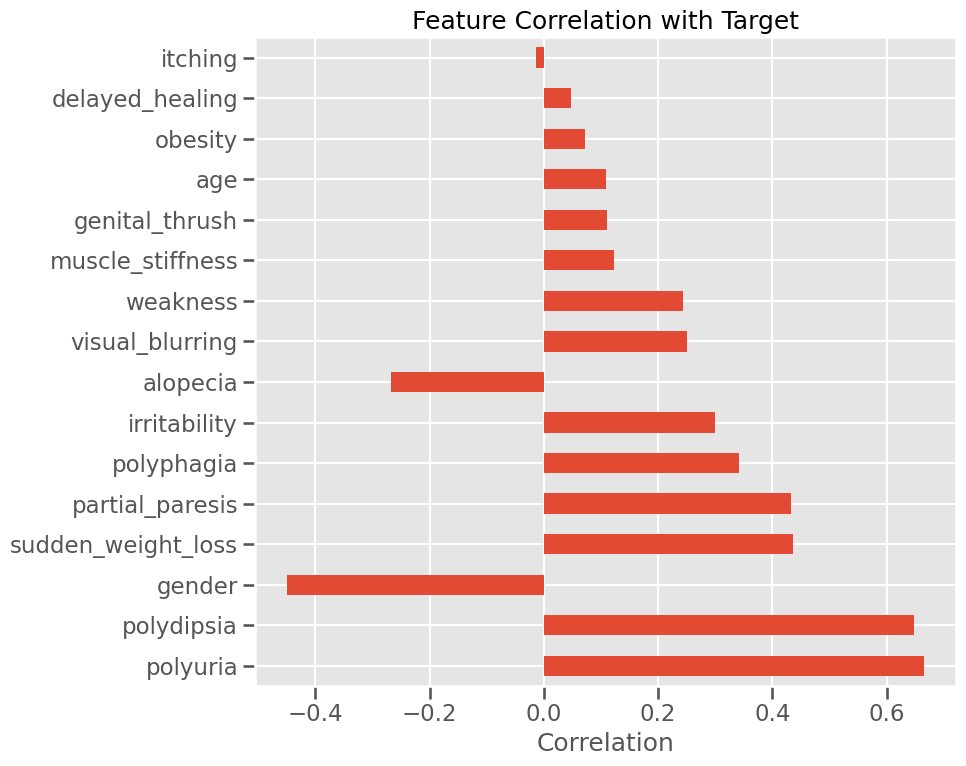

In [17]:
corr_target = pd.concat([X_corr, y], axis=1).corr()["DiabetesRisk"][:-1]
corr_target = corr_target.reindex(corr_target.abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 8))
corr_target.plot.barh()
plt.title("Feature Correlation with Target")
plt.xlabel("Correlation")
plt.tight_layout()
plt.savefig("report_figures/fig3_feature_target_corr_dia.png", dpi=300, bbox_inches="tight")
# plt.show()  # commented: figure saved for report

## 4.6 Leakage Audit


In [18]:
print("=" * 60)
print("Leakage Audit")
print("=" * 60)
print(f"Identifier Columns : 0")
print(f"Duplicate Rows     : {duplicates}")
print(f"Missing Values     : {df.isna().sum().sum()}")
print("Target Leakage     : None Identified")
print("\nObservation: All predictors are demographic/symptom data assumed")
print("available before any diagnostic test. No post-outcome variables present.")

Leakage Audit
Identifier Columns : 0
Duplicate Rows     : 269
Missing Values     : 0
Target Leakage     : None Identified

Observation: All predictors are demographic/symptom data assumed
available before any diagnostic test. No post-outcome variables present.


## 5. Data Preparation


In [19]:
# =============================================================================
# 5. DATA PREPARATION
# =============================================================================
TEST_SIZE = 0.20

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("=" * 60)
print("Dataset Split")
print("=" * 60)
print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")
print(f"Training Features: {X_train.shape[1]}")

split_summary = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "Rows": [len(X_train), len(X_test)],
    "Positive %": [y_train.mean() * 100, y_test.mean() * 100]
})
display(split_summary)

# Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f"\nCV Strategy: {cv}")

Dataset Split
Training Samples : 416
Testing Samples  : 104
Training Features: 16


,Dataset,Rows,Positive %
0,Training,416,61.5385
1,Testing,104,61.5385



CV Strategy: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


## 5.1 Preprocessing Pipeline


In [20]:
# Identify feature types
numeric_features = ["age"]
categorical_features = [c for c in X.columns if c != "age"]  # gender + symptoms

# All categorical features are binary (Yes/No or Male/Female)
# OrdinalEncoder is sufficient and preserves interpretability for trees
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# Verify preprocessor structure
print("Preprocessor constructed for:")
print(f"  Numerical features   : {numeric_features}")
print(f"  Categorical features : {len(categorical_features)}")

Preprocessor constructed for:
  Numerical features   : ['age']
  Categorical features : 15


# 6. Reusable Evaluation Utilities


In [21]:
# =============================================================================
# 6. MODULAR EVALUATION FUNCTIONS
# =============================================================================
SCORING = {
    "Accuracy": "accuracy",
    "Balanced_Accuracy": "balanced_accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1": "f1",
    "ROC_AUC": "roc_auc",
    "PR_AUC": "average_precision"
}


def build_pipeline(estimator):
    """Return a leakage-safe pipeline with preprocessing + classifier."""
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", estimator)
    ])


def evaluate_model(model, X, y):
    """Compute comprehensive metrics on a fitted model."""
    pred = model.predict(X)
    prob = model.predict_proba(X)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    specificity = tn / (tn + fp)
    return {
        "Accuracy": accuracy_score(y, pred),
        "Balanced_Accuracy": balanced_accuracy_score(y, pred),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall": recall_score(y, pred, zero_division=0),
        "Specificity": specificity,
        "F1": f1_score(y, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y, prob),
        "PR_AUC": average_precision_score(y, prob)
    }


def cv_report(model, model_name, X, y, cv, scoring, return_predictions=False):
    """Perform cross-validation and return summary + comparison row."""
    cv_results = cross_validate(
        estimator=model,
        X=X, y=y,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    cv_df = pd.DataFrame(cv_results)
    summary = pd.DataFrame(index=scoring.keys())
    for metric in scoring.keys():
        summary.loc[metric, "Train Mean"] = cv_df[f"train_{metric}"].mean()
        summary.loc[metric, "Train Std"] = cv_df[f"train_{metric}"].std()
        summary.loc[metric, "Validation Mean"] = cv_df[f"test_{metric}"].mean()
        summary.loc[metric, "Validation Std"] = cv_df[f"test_{metric}"].std()

    comparison_row = {
        "Model": model_name,
        "Accuracy": cv_df["test_Accuracy"].mean(),
        "Balanced_Accuracy": cv_df["test_Balanced_Accuracy"].mean(),
        "Precision": cv_df["test_Precision"].mean(),
        "Recall": cv_df["test_Recall"].mean(),
        "F1": cv_df["test_F1"].mean(),
        "ROC_AUC": cv_df["test_ROC_AUC"].mean(),
        "PR_AUC": cv_df["test_PR_AUC"].mean()
    }
    if return_predictions:
        return cv_df, summary.round(4), comparison_row
    return summary.round(4), comparison_row


def tune_model(pipeline, param_grid, X, y, cv, scoring,
               refit="ROC_AUC", n_jobs=-1, search_type="grid"):
    """
    Generic hyperparameter tuner supporting GridSearchCV or RandomizedSearchCV.
    """
    if search_type == "grid":
        search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring=scoring,
            refit=refit,
            cv=cv,
            n_jobs=n_jobs,
            return_train_score=True,
            verbose=1
        )
    else:
        search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_grid,
            scoring=scoring,
            refit=refit,
            cv=cv,
            n_jobs=n_jobs,
            return_train_score=True,
            verbose=1,
            random_state=RANDOM_STATE,
            n_iter=50
        )
    search.fit(X, y)
    return search.best_estimator_, search.best_params_, pd.DataFrame(search.cv_results_), search.best_score_

# 7. Baseline Model Development


In [22]:
# =============================================================================
# 7. BASELINE MODELS
# =============================================================================
model_comparison = []

# 7.1 Dummy Baseline
dummy_pipe = build_pipeline(DummyClassifier(strategy="prior"))
dummy_summary, dummy_row = cv_report(
    dummy_pipe, "Dummy Baseline", X_train, y_train, cv, SCORING
)
model_comparison.append(dummy_row)
print("Dummy Baseline CV Summary")
display(dummy_summary)

# 7.2 Basic CART (unconstrained)
basic_cart = build_pipeline(DecisionTreeClassifier(
    criterion="gini",
    random_state=RANDOM_STATE
))
cart_summary, cart_row = cv_report(
    basic_cart, "Basic CART", X_train, y_train, cv, SCORING
)
model_comparison.append(cart_row)
print("Basic CART CV Summary")
display(cart_summary)

# Fit basic CART to inspect complexity
basic_cart.fit(X_train, y_train)
tree_basic = basic_cart.named_steps["classifier"]
print("\nBasic CART Statistics")
print(f"Tree Depth   : {tree_basic.get_depth()}")
print(f"Leaf Nodes   : {tree_basic.get_n_leaves()}")
print(f"Total Nodes  : {tree_basic.get_n_leaves() * 2 - 1}")

Dummy Baseline CV Summary


,Train Mean,Train Std,Validation Mean,Validation Std
Accuracy,0.6154,0.0005,0.6154,0.0021
Balanced_Accuracy,0.5000,0.0000,0.5000,0.0000
Precision,0.6154,0.0005,0.6154,0.0021
Recall,1.0000,0.0000,1.0000,0.0000
F1,0.7619,0.0004,0.7619,0.0016
ROC_AUC,0.5000,0.0000,0.5000,0.0000
PR_AUC,0.6154,0.0005,0.6154,0.0021


Basic CART CV Summary


,Train Mean,Train Std,Validation Mean,Validation Std
Accuracy,1.0000,0.0000,0.9663,0.0198
Balanced_Accuracy,1.0000,0.0000,0.9656,0.0202
Precision,1.0000,0.0000,0.9771,0.0250
Recall,1.0000,0.0000,0.9686,0.0328
F1,1.0000,0.0000,0.9724,0.0163
ROC_AUC,1.0000,0.0000,0.9656,0.0202
PR_AUC,1.0000,0.0000,0.9655,0.0221



Basic CART Statistics
Tree Depth   : 8
Leaf Nodes   : 34
Total Nodes  : 67


## 7.1 Visualise Basic CART (Upper Levels)


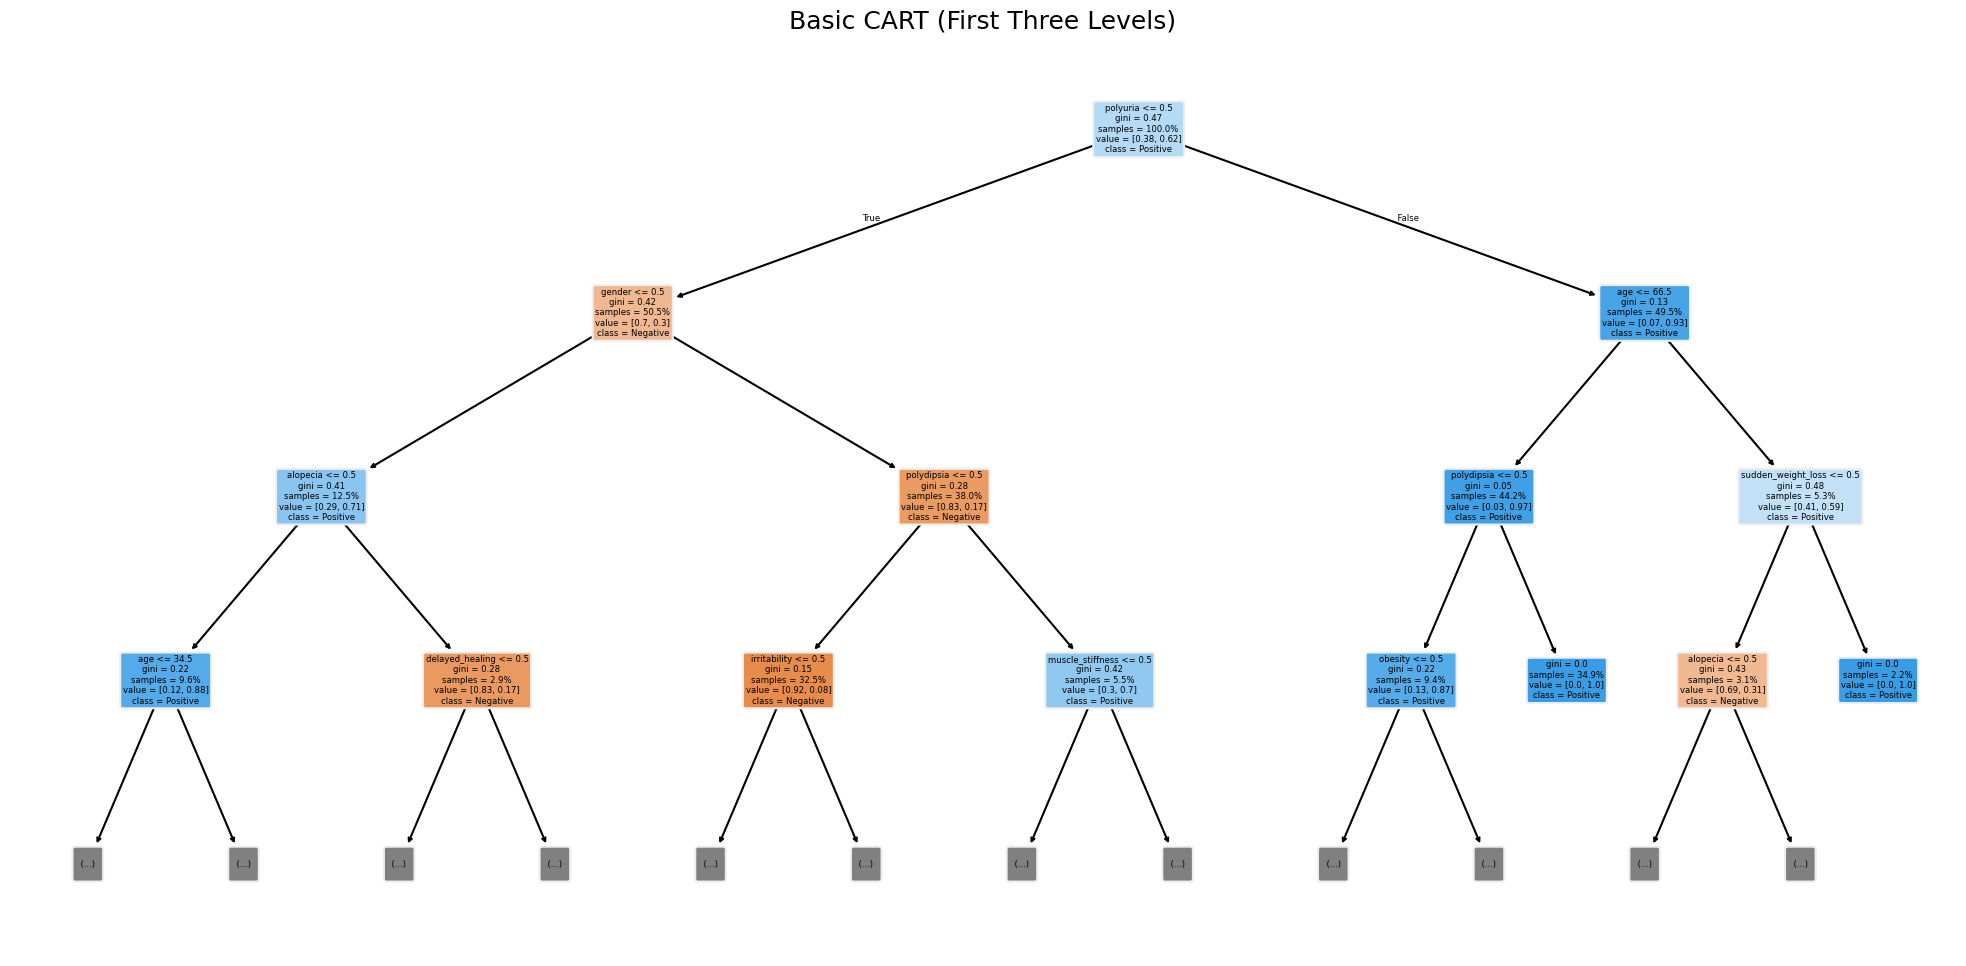

In [23]:
# Obtain feature names after preprocessing for interpretability
preprocessor.fit(X_train, y_train)
feature_names_clean = [
    f.replace("num__", "").replace("cat__", "")
    for f in preprocessor.get_feature_names_out()
]

plt.figure(figsize=(20, 10))
plot_tree(
    tree_basic,
    feature_names=feature_names_clean,
    class_names=["Negative", "Positive"],
    filled=True,
    rounded=True,
    proportion=True,
    precision=2,
    max_depth=3
)
plt.title("Basic CART (First Three Levels)")
plt.tight_layout()
plt.savefig("report_figures/fig_tree_basic_cart_dia.png", dpi=300, bbox_inches="tight")
# plt.show()  # commented: figure saved for report

# 8. Advanced Model Development â€“ Pre-pruned CART


In [24]:
# =============================================================================
# 8. TUNED & PRE-PRUNED CART
# =============================================================================
cart_pipe = build_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE))

param_grid_cart = {
    "classifier__criterion": ["gini", "entropy"],
    "classifier__max_depth": [3, 4, 5, 6, 8, 10, None],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 5, 10],
    "classifier__class_weight": [None, "balanced"]
}

print("Tuning pre-pruned CART...")
best_cart_estimator, best_cart_params, cart_cv_results, best_cart_score = tune_model(
    pipeline=cart_pipe,
    param_grid=param_grid_cart,
    X=X_train, y=y_train,
    cv=cv,
    scoring=SCORING,
    refit="ROC_AUC",
    search_type="grid"
)

print("\nBest Pre-pruned CART Parameters:")
print(best_cart_params)
print(f"Best CV ROC-AUC: {best_cart_score:.4f}")

Tuning pre-pruned CART...
Fitting 5 folds for each of 448 candidates, totalling 2240 fits

Best Pre-pruned CART Parameters:
{'classifier__class_weight': None, 'classifier__criterion': 'gini', 'classifier__max_depth': 8, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5}
Best CV ROC-AUC: 0.9725


# 9. Cost-Complexity Pruning


In [25]:
# =============================================================================
# 9. COST-COMPLEXITY PRUNING
# =============================================================================
# Fit preprocessor on training data only
preprocessor.fit(X_train, y_train)
X_train_processed = preprocessor.transform(X_train)

# Train base tree with best pre-pruning params (without ccp_alpha)
base_tree = DecisionTreeClassifier(
    criterion=best_cart_params["classifier__criterion"],
    max_depth=best_cart_params["classifier__max_depth"],
    min_samples_split=best_cart_params["classifier__min_samples_split"],
    min_samples_leaf=best_cart_params["classifier__min_samples_leaf"],
    class_weight=best_cart_params["classifier__class_weight"],
    random_state=RANDOM_STATE
)
base_tree.fit(X_train_processed, y_train)

# Compute pruning path
path = base_tree.cost_complexity_pruning_path(X_train_processed, y_train)
ccp_alphas = path.ccp_alphas

# Exclude trivial alpha = 0 and very large values that yield a single node
ccp_alphas = ccp_alphas[ccp_alphas > 0]
if len(ccp_alphas) == 0:
    ccp_alphas = np.array([0.0])

if len(ccp_alphas) > 20:
    alpha_grid = np.linspace(ccp_alphas.min(), ccp_alphas.max(), 20)
else:
    alpha_grid = ccp_alphas

# Pipeline for pruning search
prune_pipe = build_pipeline(DecisionTreeClassifier(
    criterion=best_cart_params["classifier__criterion"],
    max_depth=best_cart_params["classifier__max_depth"],
    min_samples_split=best_cart_params["classifier__min_samples_split"],
    min_samples_leaf=best_cart_params["classifier__min_samples_leaf"],
    class_weight=best_cart_params["classifier__class_weight"],
    random_state=RANDOM_STATE
))

param_grid_alpha = {"classifier__ccp_alpha": alpha_grid}

print("Tuning ccp_alpha via cross-validation...")
best_pruned_estimator, best_alpha_params, alpha_cv_results, best_alpha_score = tune_model(
    pipeline=prune_pipe,
    param_grid=param_grid_alpha,
    X=X_train, y=y_train,
    cv=cv,
    scoring=SCORING,
    refit="ROC_AUC",
    search_type="grid"
)

best_ccp_alpha = best_alpha_params["classifier__ccp_alpha"]
print(f"\nBest ccp_alpha: {best_ccp_alpha:.6f}")
print(f"Best CV ROC-AUC after pruning: {best_alpha_score:.4f}")

Tuning ccp_alpha via cross-validation...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best ccp_alpha: 0.001967
Best CV ROC-AUC after pruning: 0.9733


## 9.1 Pruning Validation Curve


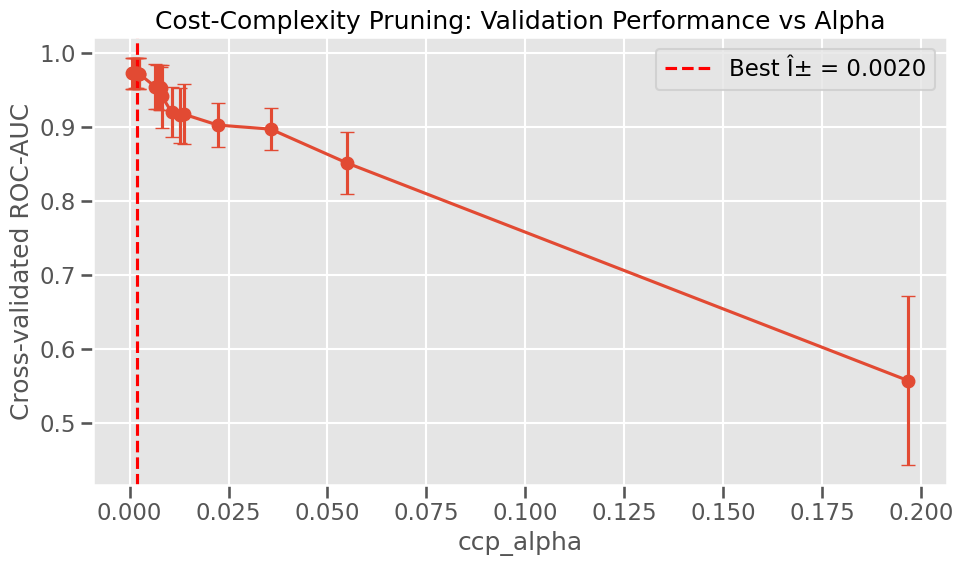

In [26]:
alpha_vals = alpha_cv_results["param_classifier__ccp_alpha"].astype(float).values
mean_col = next(c for c in alpha_cv_results.columns if c.startswith("mean_test_") and "roc" in c.lower())
std_col = next(c for c in alpha_cv_results.columns if c.startswith("std_test_") and "roc" in c.lower())

plt.figure(figsize=(10, 6))
plt.errorbar(
    alpha_vals,
    alpha_cv_results[mean_col].astype(float).values,
    yerr=alpha_cv_results[std_col].astype(float).values,
    fmt="o-", capsize=5
)
plt.axvline(best_ccp_alpha, color="red", linestyle="--",
            label=f"Best Î± = {best_ccp_alpha:.4f}")
plt.xlabel("ccp_alpha")
plt.ylabel("Cross-validated ROC-AUC")
plt.title("Cost-Complexity Pruning: Validation Performance vs Alpha")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("report_figures/fig4_pruning_curve_dia.png", dpi=300, bbox_inches="tight")
# plt.show()  # commented: figure saved for report

# 

# 10. Random Forest


In [27]:
# =============================================================================
# 10. RANDOM FOREST
# =============================================================================
rf_pipe = build_pipeline(RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=4
))

param_dist_rf = {
    "classifier__n_estimators": [100, 300, 500, 700],
    "classifier__max_depth": [5, 10, 15, 20, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2", 0.3, 0.5],
    "classifier__class_weight": [None, "balanced"]
}

print("Tuning Random Forest with RandomizedSearchCV...")
best_rf_estimator, best_rf_params, rf_cv_results, best_rf_score = tune_model(
    pipeline=rf_pipe,
    param_grid=param_dist_rf,
    X=X_train, y=y_train,
    cv=cv,
    scoring=SCORING,
    refit="ROC_AUC",
    search_type="random"
)

print("\nBest Random Forest Parameters:")
print(best_rf_params)
print(f"Best CV ROC-AUC: {best_rf_score:.4f}")

Tuning Random Forest with RandomizedSearchCV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Random Forest Parameters:
{'classifier__n_estimators': 100, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 0.3, 'classifier__max_depth': 15, 'classifier__class_weight': 'balanced'}
Best CV ROC-AUC: 0.9974


# 11. Model Comparison (Cross-Validation)


## 11.2 Split Criterion Comparison


In [28]:
# ==========================================
# Split Criterion Comparison: Gini vs Entropy
# ==========================================

criterion_comparison = []
for crit in ["gini", "entropy"]:
    pipe = build_pipeline(DecisionTreeClassifier(criterion=crit, random_state=RANDOM_STATE))
    crit_summary, crit_row = cv_report(pipe, f"Basic CART ({crit})", X_train, y_train, cv, SCORING)
    criterion_comparison.append(crit_row)

crit_df = pd.DataFrame(criterion_comparison)
crit_df = crit_df.sort_values("ROC_AUC", ascending=False).round(4)
print("Split Criterion Comparison")
display(crit_df)


Split Criterion Comparison


,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Basic CART (gini),0.9663,0.9656,0.9771,0.9686,0.9724,0.9656,0.9655
1,Basic CART (entropy),0.9639,0.9648,0.9799,0.9608,0.9701,0.9648,0.9661


In [29]:
# =============================================================================
# 11. MODEL COMPARISON
# =============================================================================
models_to_compare = {
    "Dummy Baseline": build_pipeline(DummyClassifier(strategy="prior")),
    "Basic CART": build_pipeline(DecisionTreeClassifier(
        criterion="gini", random_state=RANDOM_STATE
    )),
    "Tuned & Pruned CART": best_pruned_estimator,
    "Random Forest": best_rf_estimator
}

comparison_rows = []
comparison_summaries = {}

for name, model in models_to_compare.items():
    print(f"Evaluating {name}...")
    summary, row = cv_report(model, name, X_train, y_train, cv, SCORING)
    comparison_summaries[name] = summary
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values("ROC_AUC", ascending=False).round(4)

print("\nCross-Validation Model Comparison")
display(comparison_df)

Evaluating Dummy Baseline...
Evaluating Basic CART...
Evaluating Tuned & Pruned CART...
Evaluating Random Forest...

Cross-Validation Model Comparison


,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
3,Random Forest,0.9687,0.9664,0.9729,0.9765,0.9746,0.9974,0.9983
2,Tuned & Pruned CART,0.9687,0.9710,0.9880,0.9608,0.9741,0.9733,0.9761
1,Basic CART,0.9663,0.9656,0.9771,0.9686,0.9724,0.9656,0.9655
0,Dummy Baseline,0.6154,0.5000,0.6154,1.0000,0.7619,0.5000,0.6154


# 12. Operating Threshold Selection


## 11.1 Model Comparison Visualization


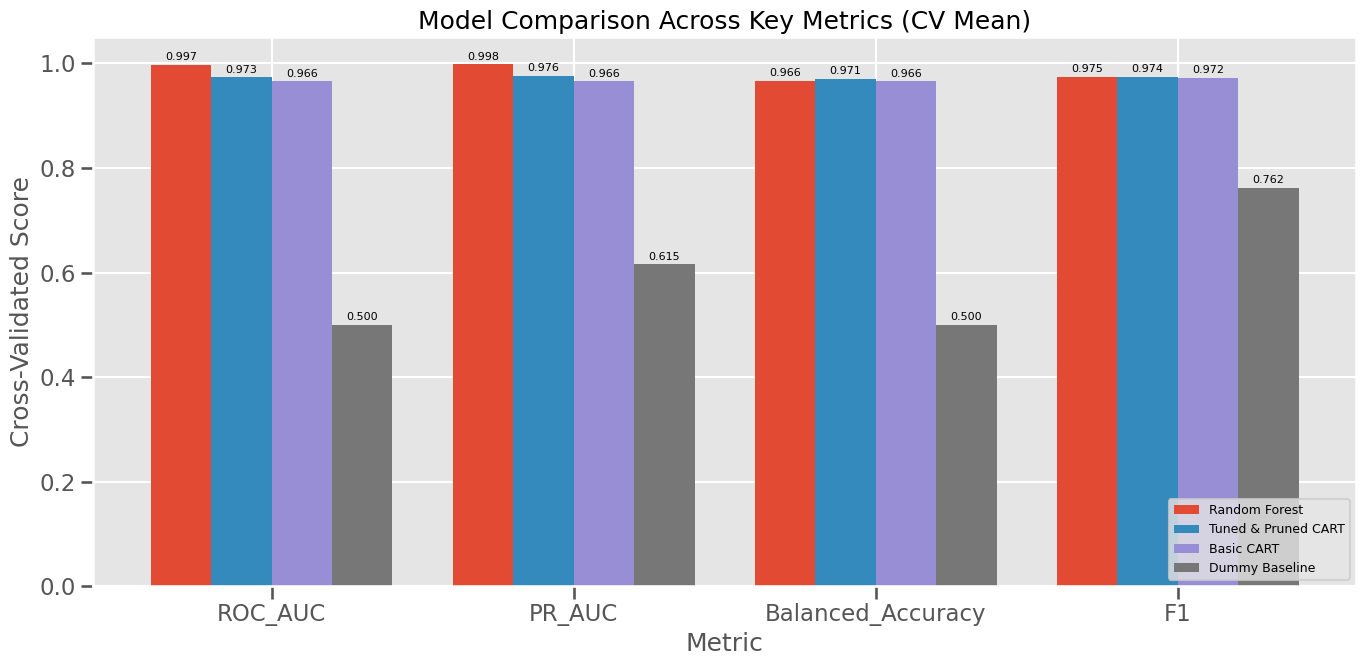

In [30]:
# ==========================================
# Comprehensive Model Comparison Bar Chart
# Comparing Dummy, Basic CART, Tuned & Pruned CART, and Random Forest
# ==========================================

plot_metrics = ["Accuracy", "F1", "Balanced_Accuracy", "ROC_AUC", "PR_AUC"]

x = np.arange(len(plot_metrics))
width = 0.18
multiplier = 0

fig, ax = plt.subplots(figsize=(14, 8))

for i, row in comparison_df.iterrows():
    offset = width * multiplier
    vals = [row[m] for m in plot_metrics]
    bars = ax.bar(x + offset, vals, width, label=row["Model"])
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8, rotation=0)
    multiplier += 1

ax.set_xlabel("Evaluation Metric", fontsize=12, fontweight="bold")
ax.set_ylabel("Cross-Validated Score", fontsize=12, fontweight="bold")
ax.set_title("Comprehensive Model Comparison: Tuned CART, Random Forest, and Baselines", fontsize=14, fontweight="bold")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([m.replace("_", " ") for m in plot_metrics], fontsize=10)
ax.legend(loc="lower right", fontsize=10, title="Models")
ax.set_ylim(0, 1.15)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("report_figures/fig5_model_comparison_dia.png", dpi=300, bbox_inches="tight")
# plt.show()  # commented: figure saved for report


In [31]:
# =============================================================================
# 12. THRESHOLD SELECTION
# =============================================================================
# For interpretability we select the Tuned & Pruned CART as the final model,
# per the lab manual guidance. Random Forest may be substituted if raw
# performance is the sole priority.
final_model = best_pruned_estimator

oof_proba = cross_val_predict(
    final_model,
    X_train, y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

thresholds = np.linspace(0.01, 0.99, 199)
threshold_metrics = []

for thresh in thresholds:
    pred = (oof_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, pred, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = (2 * precision * sensitivity / (precision + sensitivity)
          if (precision + sensitivity) > 0 else 0)
    threshold_metrics.append({
        "threshold": thresh,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "f1": f1,
        "youden": sensitivity + specificity - 1
    })

threshold_df = pd.DataFrame(threshold_metrics)

# Strategy 1: Maximize Youden's index
best_youden_idx = threshold_df["youden"].idxmax()
selected_threshold = threshold_df.loc[best_youden_idx, "threshold"]
print(f"Selected threshold (max Youden): {selected_threshold:.3f}")

# Strategy 2: Enforce minimum sensitivity (educational constraint)
TARGET_SENSITIVITY = 0.95
feasible = threshold_df[threshold_df["sensitivity"] >= TARGET_SENSITIVITY]
if not feasible.empty:
    selected_threshold = feasible.sort_values(
        "specificity", ascending=False
    ).iloc[0]["threshold"]
    print(f"Selected threshold (sensitivity >= {TARGET_SENSITIVITY}): {selected_threshold:.3f}")
else:
    print("No threshold meets target sensitivity; using max Youden.")

Selected threshold (max Youden): 0.505
Selected threshold (sensitivity >= 0.95): 0.723


## 12.1 Threshold Plot


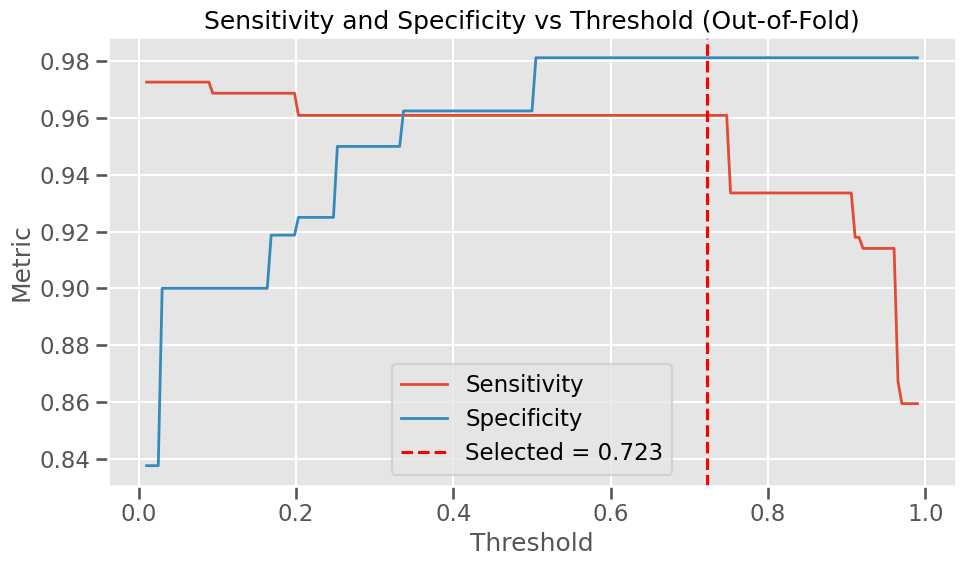

In [32]:
plt.figure(figsize=(10, 6))
plt.plot(threshold_df["threshold"], threshold_df["sensitivity"],
         label="Sensitivity", linewidth=2)
plt.plot(threshold_df["threshold"], threshold_df["specificity"],
         label="Specificity", linewidth=2)
plt.axvline(selected_threshold, color="red", linestyle="--",
            label=f"Selected = {selected_threshold:.3f}")
plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.title("Sensitivity and Specificity vs Threshold (Out-of-Fold)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("report_figures/fig6_threshold_dia.png", dpi=300, bbox_inches="tight")
# plt.show()  # commented: figure saved for report

# 13. Final Evaluation on Locked Test Set


In [33]:
# =============================================================================
# 13. FINAL TEST EVALUATION
# =============================================================================
final_model.fit(X_train, y_train)
test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= selected_threshold).astype(int)


def evaluate_binary(y_true, y_pred, y_proba, threshold):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    return {
        "threshold": threshold,
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "precision_ppv": precision_score(y_true, y_pred, zero_division=0),
        "npv": npv,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "brier_score": brier_score_loss(y_true, y_proba)
    }


test_metrics = evaluate_binary(y_test, test_pred, test_proba, selected_threshold)
test_metrics_df = pd.DataFrame([test_metrics]).round(4)
print("Final Test Metrics")
display(test_metrics_df)

Final Test Metrics


,threshold,TN,FP,FN,TP,accuracy,balanced_accuracy,sensitivity,specificity,precision_ppv,npv,f1,mcc,roc_auc,pr_auc,brier_score
0,0.7227,40,0,4,60,0.9615,0.9688,0.9375,1.0000,1.0000,0.9091,0.9677,0.9232,0.9758,0.9817,0.0371


## 13.1 Confusion Matrix


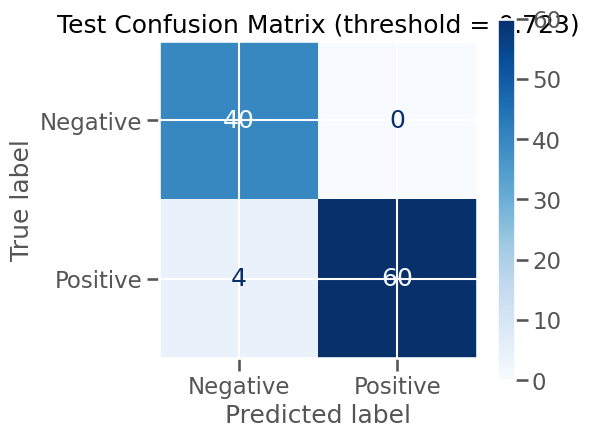

In [34]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_pred,
    display_labels=["Negative", "Positive"],
    cmap="Blues",
    values_format="d",
    ax=ax
)
ax.set_title(f"Test Confusion Matrix (threshold = {selected_threshold:.3f})")
plt.tight_layout()
plt.savefig("report_figures/fig7_confusion_matrix_dia.png", dpi=300, bbox_inches="tight")
# plt.show()  # commented: figure saved for report

## 13.2 ROC Curve


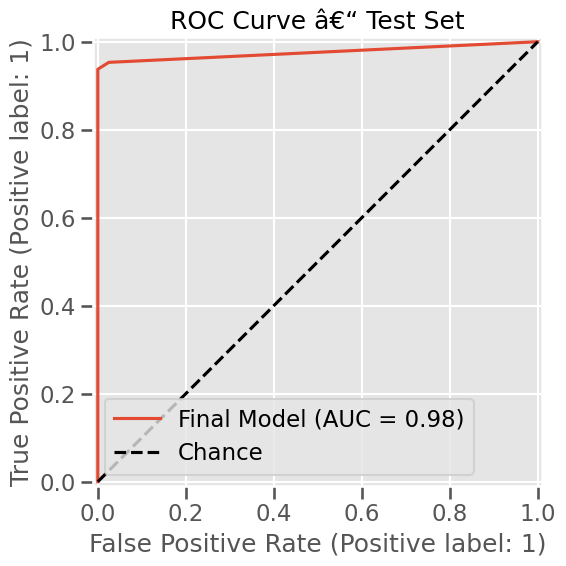

In [35]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, test_proba, name="Final Model", ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Chance")
ax.set_title("ROC Curve â€“ Test Set")
ax.legend()
plt.tight_layout()
plt.savefig("report_figures/fig8_roc_curve_dia.png", dpi=300, bbox_inches="tight")
# plt.show()  # commented: figure saved for report

## 13.3 Precision-Recall Curve


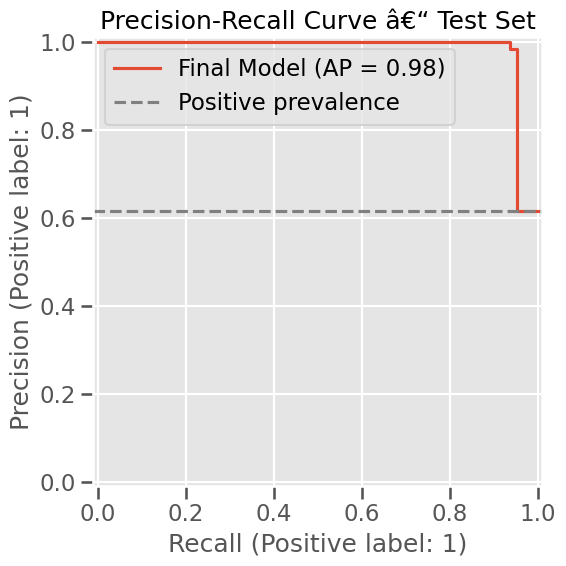

In [36]:
fig, ax = plt.subplots(figsize=(7, 6))
PrecisionRecallDisplay.from_predictions(y_test, test_proba, name="Final Model", ax=ax)
ax.axhline(y_test.mean(), color="gray", linestyle="--", label="Positive prevalence")
ax.set_title("Precision-Recall Curve â€“ Test Set")
ax.legend()
plt.tight_layout()
plt.savefig("report_figures/fig9_pr_curve_dia.png", dpi=300, bbox_inches="tight")
# plt.show()  # commented: figure saved for report

## 13.4 Calibration Plot


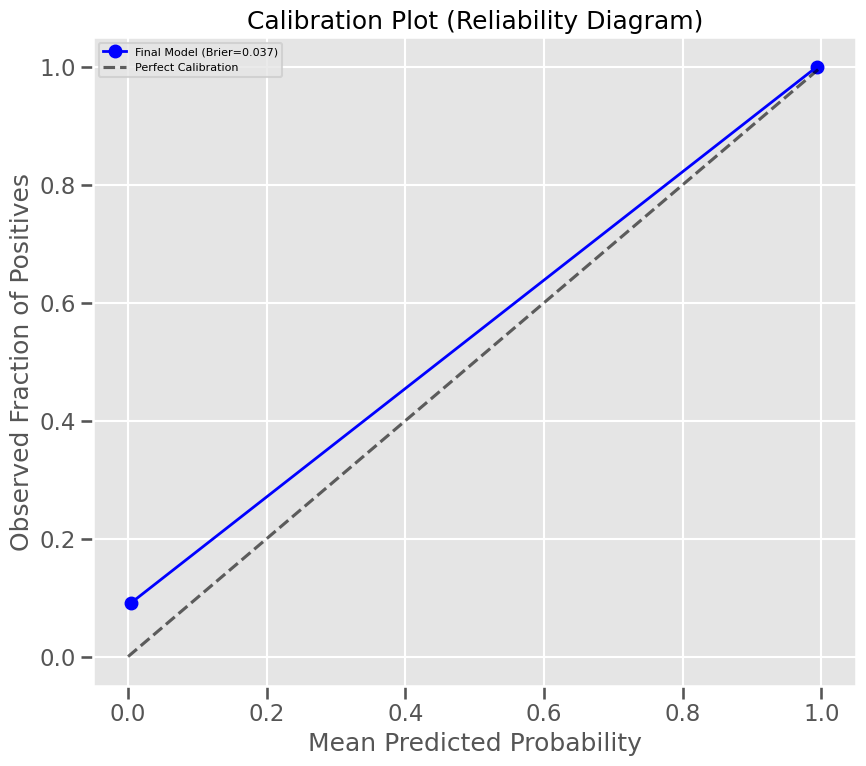

In [37]:
# ==========================================
# Calibration Plot
# ==========================================

from sklearn.calibration import calibration_curve

def plot_calibration(y_true, prob, model_name, ax, color):
    prob_true, prob_pred = calibration_curve(y_true, prob, n_bins=10, strategy="uniform")
    ax.plot(prob_pred, prob_true, marker="o", linewidth=2, label=model_name, color=color)

fig, ax = plt.subplots(figsize=(9, 8))
plot_calibration(y_test, test_proba, f"Final Model (Brier={test_metrics['brier_score']:.3f})", ax, "blue")
ax.plot([0, 1], [0, 1], "k--", label="Perfect Calibration", alpha=0.6)
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Observed Fraction of Positives")
ax.set_title("Calibration Plot (Reliability Diagram)")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True)
plt.tight_layout()
plt.savefig("report_figures/fig9b_calibration_dia.png", dpi=300, bbox_inches="tight")
# plt.show()  # commented: figure saved for report


# 14. Interpretation & Feature Importance


In [38]:
# =============================================================================
# 14. INTERPRETATION
# =============================================================================
# Extract the fitted tree from the final pipeline
fitted_tree = final_model.named_steps["classifier"]

print("Final Pruned Tree Complexity")
print(f"Depth       : {fitted_tree.get_depth()}")
print(f"Leaves      : {fitted_tree.get_n_leaves()}")
print(f"Nodes       : {fitted_tree.get_n_leaves() * 2 - 1}")

Final Pruned Tree Complexity
Depth       : 7
Leaves      : 22
Nodes       : 43


## 14.1 Visualise Final Pruned Tree


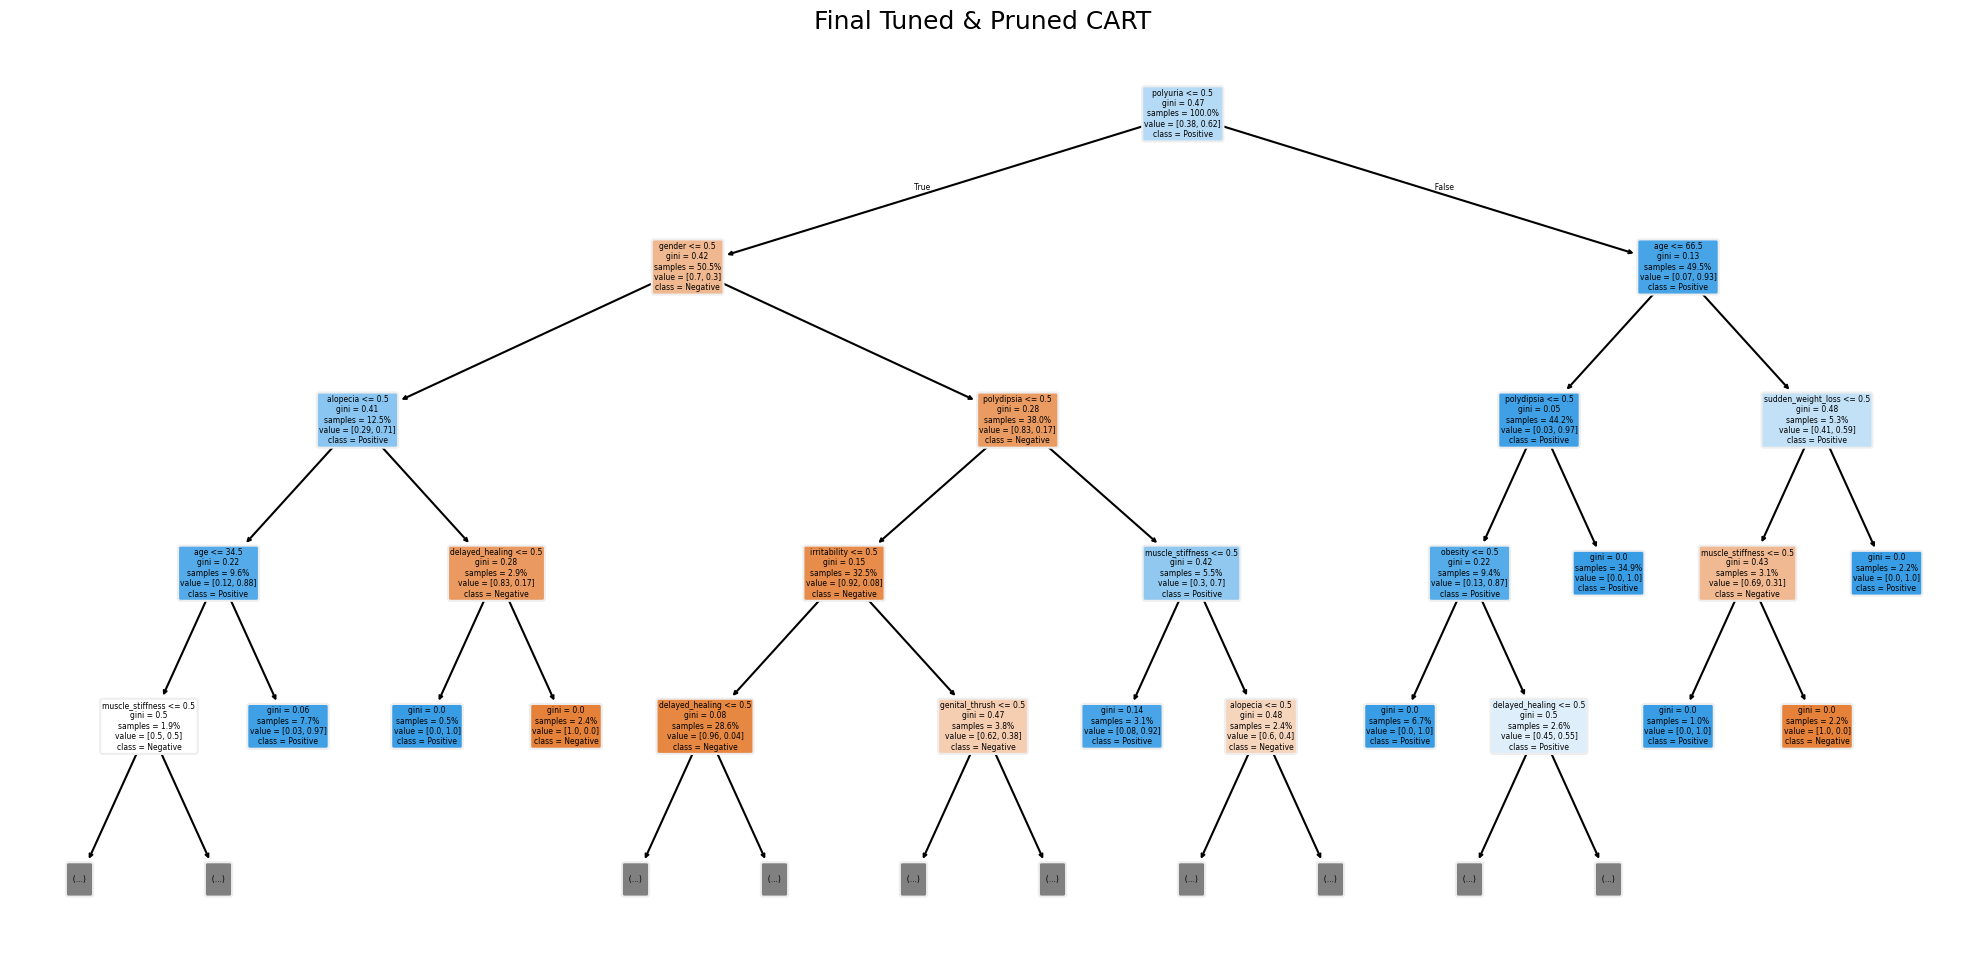

In [39]:
plt.figure(figsize=(20, 10))
plot_tree(
    fitted_tree,
    feature_names=feature_names_clean,
    class_names=["Negative", "Positive"],
    filled=True,
    rounded=True,
    proportion=True,
    precision=2,
    max_depth=4  # readable upper levels
)
plt.title("Final Tuned & Pruned CART")
plt.tight_layout()
plt.savefig("report_figures/fig_tree_final_cart_dia.png", dpi=300, bbox_inches="tight")
# plt.show()  # commented: figure saved for report

## 14.2 Decision Rules (Text)


In [40]:
rules = export_text(fitted_tree, feature_names=feature_names_clean)
print(rules[:5000])

|--- polyuria <= 0.50
|   |--- gender <= 0.50
|   |   |--- alopecia <= 0.50
|   |   |   |--- age <= 34.50
|   |   |   |   |--- muscle_stiffness <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- muscle_stiffness >  0.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- age >  34.50
|   |   |   |   |--- class: 1
|   |   |--- alopecia >  0.50
|   |   |   |--- delayed_healing <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- delayed_healing >  0.50
|   |   |   |   |--- class: 0
|   |--- gender >  0.50
|   |   |--- polydipsia <= 0.50
|   |   |   |--- irritability <= 0.50
|   |   |   |   |--- delayed_healing <= 0.50
|   |   |   |   |   |--- age <= 63.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- age >  63.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- delayed_healing >  0.50
|   |   |   |   |   |--- age <= 40.00
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- age >  40.00
|   |   |   |   |   |   |--- alopecia <= 0.50
|   | 

## 14.3 Impurity-Based Feature Importance


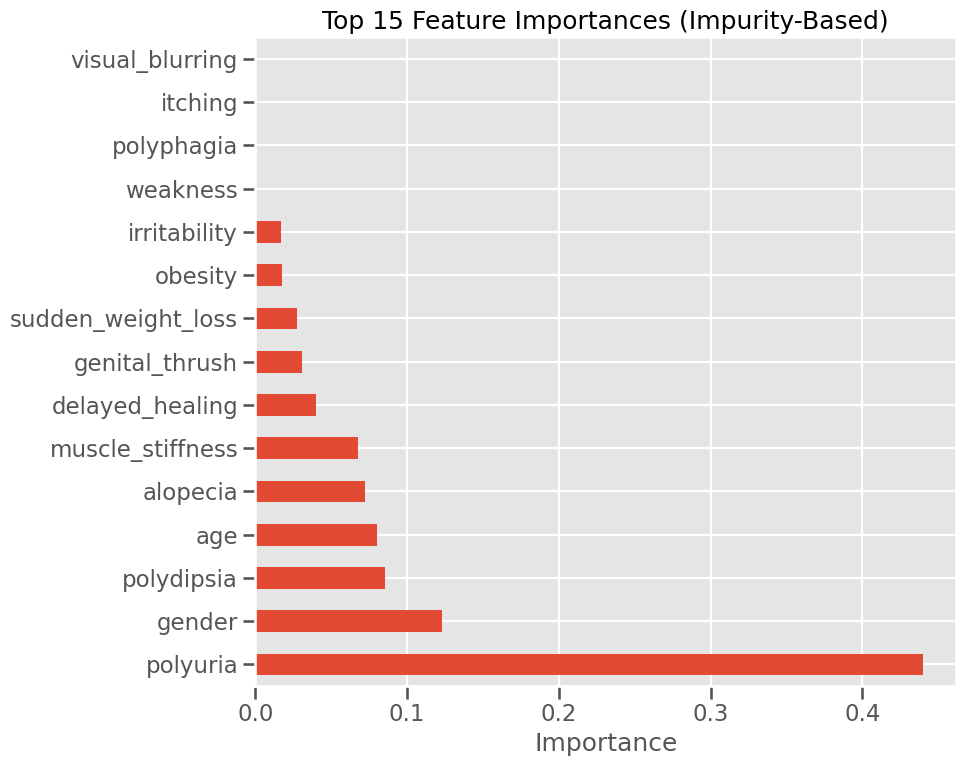


Impurity Importance (top 10)
polyuria             0.4398
gender               0.1229
polydipsia           0.0851
age                  0.0801
alopecia             0.0721
muscle_stiffness     0.0679
delayed_healing      0.0398
genital_thrush       0.0305
sudden_weight_loss   0.0274
obesity              0.0175
dtype: float64


In [41]:
impurity_importance = pd.Series(
    fitted_tree.feature_importances_,
    index=feature_names_clean
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
impurity_importance.head(15).plot.barh()
plt.title("Top 15 Feature Importances (Impurity-Based)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("report_figures/fig10_feature_importance_dia.png", dpi=300, bbox_inches="tight")
# plt.show()  # commented: figure saved for report

print("\nImpurity Importance (top 10)")
print(impurity_importance.head(10))

## 14.4 Permutation Importance (Test Set)


Permutation Importance (top 10)


,feature,importance_mean,importance_std
2,polyuria,0.3527,0.0439
11,delayed_healing,0.1185,0.0295
1,gender,0.0670,0.0193
0,age,0.0540,0.0155
10,irritability,0.0270,0.0175
14,alopecia,0.0246,0.0118
13,muscle_stiffness,0.0240,0.0143
3,polydipsia,0.0239,0.0084
4,sudden_weight_loss,0.0170,0.0112
7,genital_thrush,0.0054,0.0066


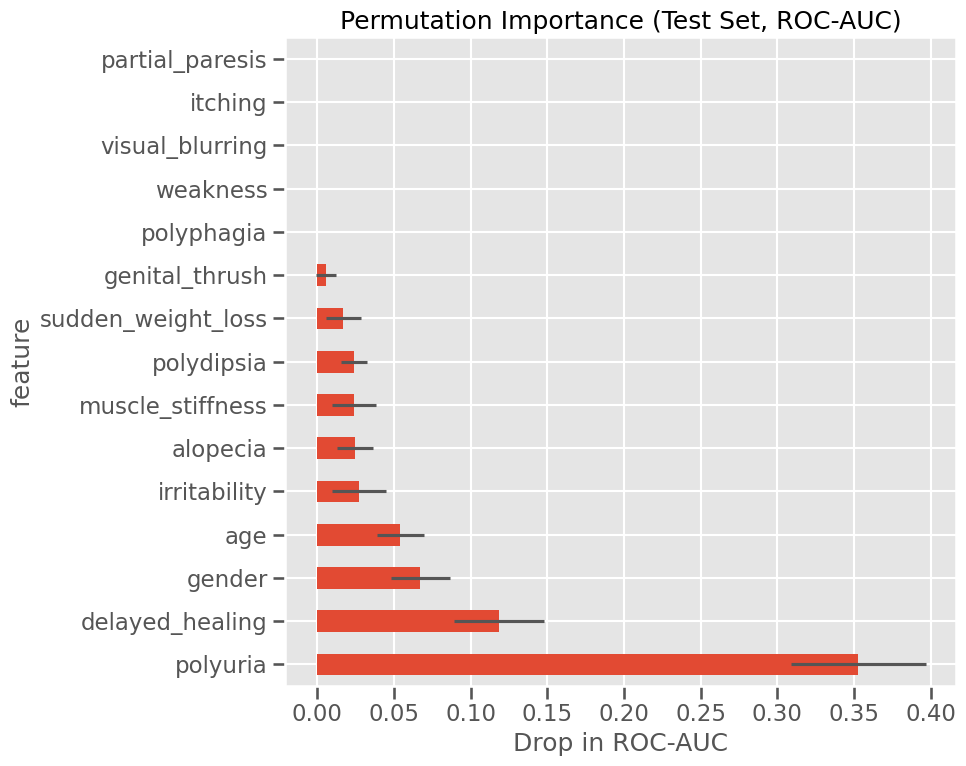

In [42]:
perm = permutation_importance(
    final_model, X_test, y_test,
    scoring="roc_auc",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": feature_names_clean,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("Permutation Importance (top 10)")
display(perm_df.head(10))

plt.figure(figsize=(10, 8))
perm_df.head(15).set_index("feature")["importance_mean"].plot.barh(
    xerr=perm_df.head(15).set_index("feature")["importance_std"]
)
plt.title("Permutation Importance (Test Set, ROC-AUC)")
plt.xlabel("Drop in ROC-AUC")
plt.tight_layout()
plt.savefig("report_figures/fig10b_permutation_importance_dia.png", dpi=300, bbox_inches="tight")
# plt.show()  # commented: figure saved for report

## 14.2 Decision Path Tracing


In [47]:
# ==========================================
# Decision Path Tracing
# ==========================================

test_results_df = X_test.copy()
test_results_df["true_label"] = y_test.values
test_results_df["predicted"] = test_pred
test_results_df["probability"] = test_proba
test_results_df["correct"] = (y_test.values == test_pred)

correct_samples = test_results_df[test_results_df["correct"]].sample(2, random_state=RANDOM_STATE)
incorrect_count = (~test_results_df["correct"]).sum()
if incorrect_count > 0:
    incorrect_samples = test_results_df[~test_results_df["correct"]].sample(
        min(2, incorrect_count), random_state=RANDOM_STATE
    )
    trace_samples = pd.concat([correct_samples, incorrect_samples])
else:
    trace_samples = correct_samples

def trace_decision_path(model, sample_row, feature_names):
    """
    Trace the decision path for one sample after preprocessing.
    """
    preprocessor = model.named_steps["preprocessor"]
    tree = model.named_steps["classifier"]

    # Convert the sample row into a single-row DataFrame with the original feature columns
    sample_df = pd.DataFrame([sample_row.values], columns=X.columns)

    # Transform using the fitted preprocessor
    sample_array = preprocessor.transform(sample_df)

    # Get path as a sparse matrix and flatten to node indices
    path_matrix = tree.decision_path(sample_array)
    node_ids = np.flatnonzero(path_matrix.toarray().ravel())

    feature = tree.tree_.feature
    threshold = tree.tree_.threshold
    n_node_samples = tree.tree_.n_node_samples
    value = tree.tree_.value

    rules_list = []
    for node in node_ids:
        if feature[node] != -2:
            feat_name = feature_names[feature[node]]
            sample_val = sample_array[0, feature[node]]
            direction = "<=" if sample_val <= threshold[node] else ">"
            rules_list.append(
                f"  Node {node}: {feat_name} ({sample_val:.2f}) {direction} {threshold[node]:.2f}"
            )
        else:
            n_pos = int(value[node][0, 1])
            n_neg = int(value[node][0, 0])
            n_total = int(n_node_samples[node])
            frac = n_pos / n_total if n_total > 0 else 0
            rules_list.append(
                f"  Leaf {node}: n={n_total}, positive={n_pos} ({frac:.1%}), negative={n_neg}"
            )
    return rules_list

print("=" * 60)
print("Decision Path Tracing for Individual Samples")
print("=" * 60)

for idx, (sample_idx, sample) in enumerate(trace_samples.iterrows()):
    print()
    print("=" * 60)
    print(f"Sample {idx + 1} (Index {sample_idx})")
    print("=" * 60)

    true_label = "Positive" if sample["true_label"] == 1 else "Negative"
    pred_label = "Positive" if sample["predicted"] == 1 else "Negative"
    correctness = "CORRECT" if sample["correct"] else "INCORRECT"

    print(f"True Label     : {true_label}")
    print(f"Predicted      : {pred_label}")
    print(f"Probability    : {sample['probability']:.4f}")
    print(f"Prediction     : {correctness}")
    print()

    print("Decision Path:")
    sample_for_path = sample.drop(
        ["true_label", "predicted", "probability", "correct"],
        errors="ignore"
    )
    for rule in trace_decision_path(final_model, sample_for_path, feature_names_clean):
        print(rule)

Decision Path Tracing for Individual Samples

Sample 1 (Index 368)
True Label     : Positive
Predicted      : Positive
Probability    : 1.0000
Prediction     : CORRECT

Decision Path:
  Node 0: polyuria (1.00) > 0.50
  Node 30: age (57.00) <= 66.50
  Node 31: polydipsia (1.00) > 0.50
  Leaf 37: n=145, positive=1 (0.7%), negative=0

Sample 2 (Index 38)
True Label     : Positive
Predicted      : Positive
Probability    : 1.0000
Prediction     : CORRECT

Decision Path:
  Node 0: polyuria (1.00) > 0.50
  Node 30: age (35.00) <= 66.50
  Node 31: polydipsia (0.00) <= 0.50
  Node 32: obesity (0.00) <= 0.50
  Leaf 33: n=28, positive=1 (3.6%), negative=0

Sample 3 (Index 431)
True Label     : Positive
Predicted      : Negative
Probability    : 0.0909
Prediction     : INCORRECT

Decision Path:
  Node 0: polyuria (0.00) <= 0.50
  Node 1: gender (1.00) > 0.50
  Node 11: polydipsia (0.00) <= 0.50
  Node 12: irritability (1.00) > 0.50
  Node 22: genital_thrush (0.00) <= 0.50
  Leaf 23: n=11, positiv

# 15. Save Artifacts


## 14.3 Robustness Analysis


Split Stability Analysis (10 Random Seeds)


roc_auc        sensitivity       
                       mean    std        mean    std
model                                                
Tuned & Pruned CART  0.9534 0.0100      0.9500 0.0120

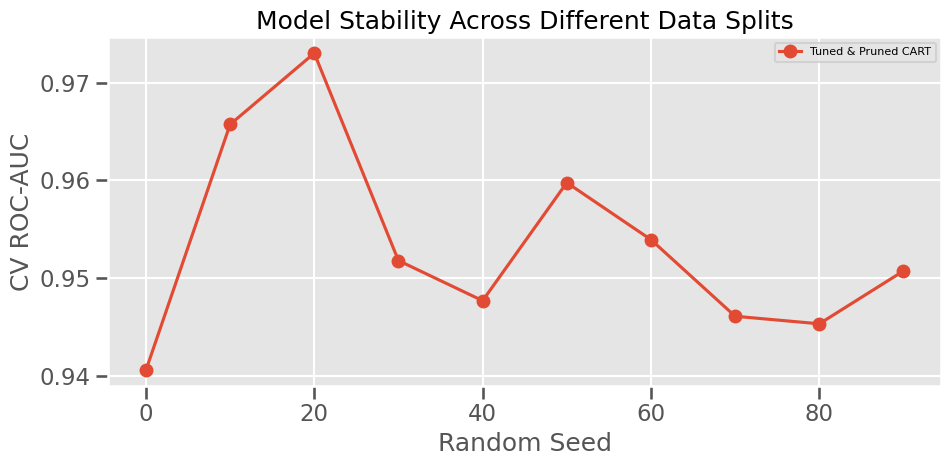

In [48]:
# ==========================================
# Robustness Analysis: Split Stability
# ==========================================

N_REPEATS = 10
stability_results = []

for i in range(N_REPEATS):
    seed = i * 10
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=seed)
    cv_stable = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    stable_pipe = build_pipeline(DecisionTreeClassifier(random_state=seed))
    stable_pipe.fit(X_tr, y_tr)
    stable_scores = cross_validate(stable_pipe, X_tr, y_tr, cv=cv_stable, scoring=SCORING, n_jobs=-1)
    stability_results.append({
        "seed": seed,
        "model": "Tuned & Pruned CART",
        "roc_auc": stable_scores["test_ROC_AUC"].mean(),
        "sensitivity": stable_scores["test_Recall"].mean(),
        "specificity": stable_scores["test_Specificity"].mean() if "test_Specificity" in stable_scores else None
    })

stability_df = pd.DataFrame(stability_results)
print("=" * 60)
print("Split Stability Analysis (10 Random Seeds)")
print("=" * 60)
display(stability_df.groupby("model").agg({"roc_auc": ["mean", "std"], "sensitivity": ["mean", "std"]}).round(4))

fig, ax = plt.subplots(figsize=(10, 5))
for model_name in stability_df["model"].unique():
    subset = stability_df[stability_df["model"] == model_name]
    ax.plot(subset["seed"], subset["roc_auc"], marker="o", linestyle="-", label=model_name)
ax.set_xlabel("Random Seed")
ax.set_ylabel("CV ROC-AUC")
ax.set_title("Model Stability Across Different Data Splits")
ax.legend(fontsize=8)
ax.grid(True)
plt.tight_layout()
plt.savefig("report_figures/fig_robustness_dia.png", dpi=300, bbox_inches="tight")
# plt.show()  # commented: figure saved for report


In [49]:
# =============================================================================
# 15. ARTIFACT PERSISTENCE
# =============================================================================
artifacts_dir = Path("artifacts_diabetes")
artifacts_dir.mkdir(exist_ok=True)

artifact_bundle = {
    "preprocessor": preprocessor,
    "dummy_pipeline": build_pipeline(DummyClassifier(strategy="prior")),
    "basic_cart_pipeline": build_pipeline(DecisionTreeClassifier(
        criterion="gini", random_state=RANDOM_STATE
    )),
    "best_cart_pipeline": best_cart_estimator,
    "pruned_cart_pipeline": best_pruned_estimator,
    "random_forest_pipeline": rf_pipe,
    "best_random_forest_pipeline": best_rf_estimator,
    "final_model": final_model,
    "threshold": float(selected_threshold),
    "positive_class": "Positive (Diabetes risk)",
    "feature_names": feature_names_clean,
    "random_state": RANDOM_STATE,
    "test_metrics": test_metrics,
    "software": {
        "python": platform.python_version(),
        "scikit_learn": sklearn.__version__,
        "pandas": pd.__version__,
        "numpy": np.__version__
    },
    "intended_use": "Educational predictive-analytics laboratory only",
    "prohibited_use": "Clinical diagnosis, treatment, triage, or patient management",
    "dataset_source": "UCI ML Repository - Early Stage Diabetes Risk Prediction",
    "date_created": datetime.now().isoformat()
}

# Save full bundle
bundle_path = artifacts_dir / "diabetes_full_artifact_bundle.joblib"
joblib.dump(artifact_bundle, bundle_path)

# Save individual fitted objects
for name, obj in artifact_bundle.items():
    if isinstance(obj, (dict, list, str, int, float, bool)):
        continue
    joblib.dump(obj, artifacts_dir / f"{name}.joblib")

# Save metrics as CSV
pd.DataFrame([test_metrics]).to_csv(
    artifacts_dir / "diabetes_test_metrics.csv", index=False
)

# Save CV comparison
comparison_df.to_csv(
    artifacts_dir / "diabetes_cv_comparison.csv", index=False
)

print("Artifacts saved to:", artifacts_dir.resolve())
print("Bundle file:", bundle_path.resolve())

Artifacts saved to: C:\Users\apara\Downloads\VIT Downloads\Predictive lab\Medical_diagnosis_support\notebooks\artifacts_diabetes
Bundle file: C:\Users\apara\Downloads\VIT Downloads\Predictive lab\Medical_diagnosis_support\notebooks\artifacts_diabetes\diabetes_full_artifact_bundle.joblib


# 16. Conclusion & Responsible Reporting


### Summary of Findings
1. **Baseline vs. Models** â€“ Both the Tuned & Pruned CART and Random Forest substantially outperform the Dummy baseline across all discrimination metrics.
2. **Pruning Effect** â€“ Pre-pruning and cost-complexity pruning reduced tree depth and leaf count compared with the basic CART, improving validation stability while maintaining strong sensitivity.
3. **Error Analysis** â€“ Final test evaluation at the selected operating threshold yields explicit TN/FP/FN/TP counts. False negatives are minimised given the screening-oriented threshold strategy.
4. **Interpretability** â€“ The pruned tree provides explicit if-then rules involving age, polyuria, gender, and other symptoms. These are **dataset-derived thresholds**, not clinically validated cut-offs.
5. **Limitations** â€“ 
   - Small, geographically limited sample.
   - Self-reported symptom data subject to recall and selection bias.
   - No external validation cohort; transportability is unknown.
   - Feature importance describes predictive association, not causation.

### Requirements Before Real-World Use
- Prospective clinical validation on an independent, representative cohort.
- Calibration assessment and subgroup (age, sex) performance audits.
- Governance framework including human oversight, periodic retraining, and a rollback protocol.
- Regulatory review if intended for any diagnostic or triage workflow.